# Root to Tip Plot from TempEst, Exported to Python

Goals:
* Time vs. genetic distance
* Color by state
* Shape by host

In [1]:
# Housekeeping

import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt
from matplotlib import pyplot
import importlib
import utils  
importlib.reload(utils)
from utils import * 

downloads = "C:/Users/maksi/Documents/Statistics/Projects/Avian_Flu_Files/"
# downloads = "C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/"
cat_files = downloads + "Cats/"



                                                    tip         date  \
0     A/Alpaca/ID/24-015080-001-original/2024|H5N1|U...  2024.382514   
1     A/american_robin/Iowa/24-018879-003/2024|H5N1|...  2024.464481   
2     A/cattle/IA/24-023669-001/2024|H5N1|USA-IA|202...  2024.614754   
3     A/cattle/IA/24-017484-006/2024|H5N1|USA-IA|202...  2024.445355   
4     A/cattle/IA/24-017484-001/2024|H5N1|USA-IA|202...  2024.445355   
...                                                 ...          ...   
2503  A/cattle/Idaho/24-011573-015/2024|H5N1|USA-ID|...  2024.286885   
2504  A/dairy_cow/Idaho/W241070094-3/2024|H5N1|USA-I...  2024.286885   
2505  A/chicken/Idaho/24-013706-002/2024|H5N1|USA-ID...  2024.346995   
2506  A/Alpaca/ID/24-014328-008/2024|H5N1|USA-ID|202...  2024.368852   
2507  A/Alpaca/ID/24-014328-011/2024|H5N1|USA-ID|202...  2024.368852   

      distance  residual   state Abbreviation     host_type            host  \
0     0.000384 -0.001181  USA-ID           ID  other_mam

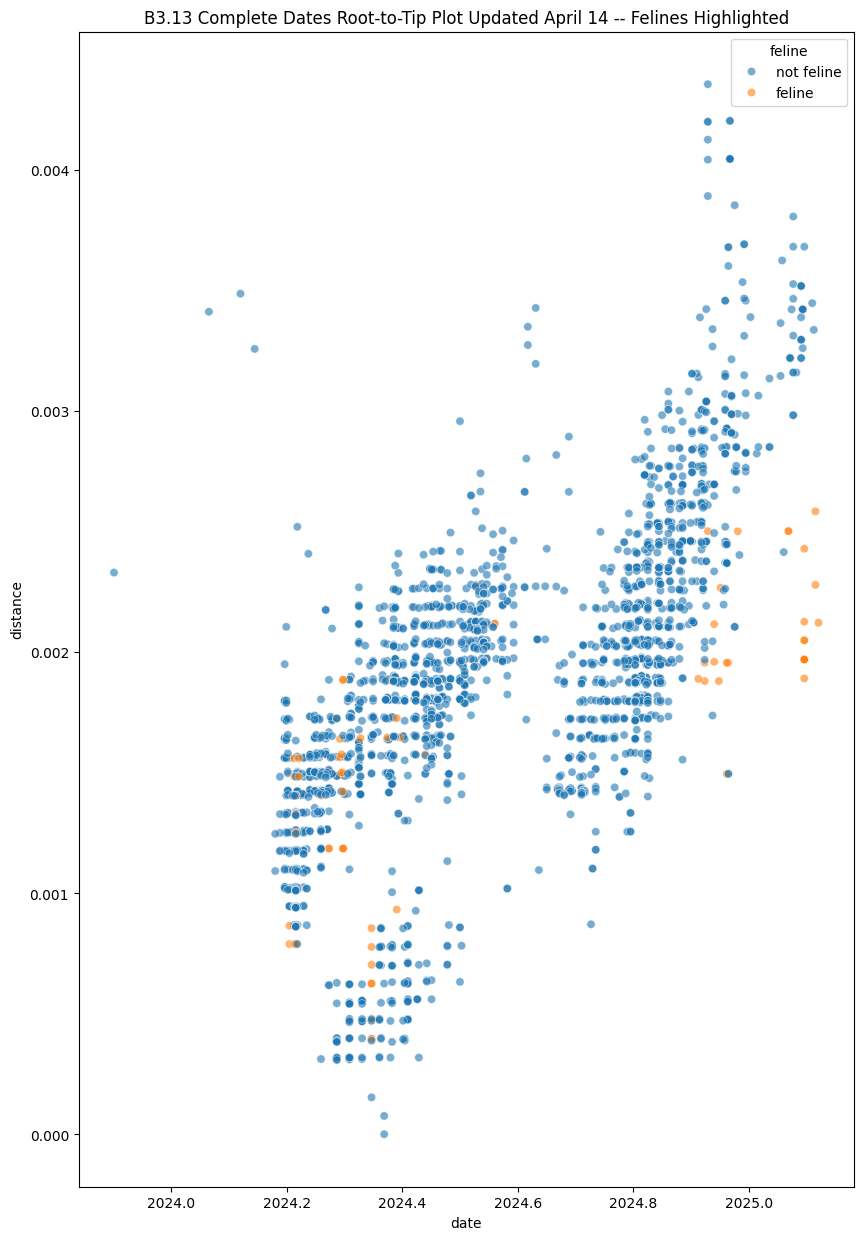

In [3]:
os.chdir(downloads)

states = pd.read_csv("states_ref.csv")
animals_ref_feline = pd.read_csv("animals_ref.csv")

os.chdir(cat_files)

df = pd.read_csv("B3_13_APR14_tempest_r2t_feline.txt", delimiter="\t")

df = df.rename(columns={"tip":"full_header"}) # relabel_animals only works with full_header

df = relabel_animals(df, animals_ref_feline)

df = df.rename(columns={"full_header": "tip"}) # change back name

df["state"] = df["tip"].apply(lambda x: x.split("|")[2])
df["Abbreviation"] = df["tip"].apply(lambda x: x.split("|")[2][4:])
df["host_type"] = df["tip"].apply(lambda x: x.split("|")[4])
df["host"] = df["tip"].apply(lambda x: x.split("/")[1].lower().replace(" ", "_").replace("'", "").replace("-","_"))
df["feline"] = df["host_type"].apply(lambda x: "feline" if x == "feline" else "not feline")

df_states = df.merge(states, on="Abbreviation")

df_states_copy = df_states

print(df_states)

# df_felines = df_states[df_states["host_type"] == "feline"]

# print(df_felines)

fig, axes = pyplot.subplots(1, 1, figsize = (10, 15))
# sns.scatterplot(ax=axes[0], data=df_states, x="date", y="distance", hue="host_type") #, style="") # All states
# sns.scatterplot(ax=axes[1], data=df_states, x="date", y="distance", hue="Division", style="host_type") # State divisions
# sns.scatterplot(ax=axes[2], data=df_states, x="date", y="distance", hue="Region", style="host_type") # USA Regions
sns.scatterplot(ax=axes, data=df_states, x="date", y="distance", hue="feline", alpha=0.6) #, style="host") # Cats only
# sns.scatterplot(ax=axes, data=df_states, x="date", y="distance", hue="Abbreviation", style="host_type", alpha=0.6)

# fig.suptitle("B3.13 Complete Dates Root-to-Tip Plots Updated April 14")
# axes[0].set_title("All States")
# axes[1].set_title("Regions")
axes.set_title("B3.13 Complete Dates Root-to-Tip Plot Updated April 14 -- Felines Highlighted")

fig.savefig("B3_13_APR14_r2t_felines_highlighted.png")


In [3]:
# # Create tsv with color annotations for host_type

# # print(df_states)

# colors = {"avian": ["#fcffa4"], "cattle": ["#fca50a"], "human": ["#dd513a"], "feline": ["#932667"], "other_mammal": ["#420a68"], "other": ["#000004"]}

# color_df = pd.DataFrame.from_dict(colors).T

# color_df["host_type"] = color_df.index
# color_df["color"] = color_df[0]
# color_df = color_df.reset_index()
# color_df = color_df[["host_type", "color"]]

# # print(color_df)

# df_states_color = df_states.merge(color_df, on="host_type")

# print(df_states_color)

# df_states_color[["tip", "host_type"]].to_csv("B3_13_APR14_annotations.tsv", sep="\t", index=False)

In [4]:
# os.chdir(cat_files)

# df = pd.read_csv("B3_13_APR14_complete_dates_relabeled_felines.csv")

# df["state"] = df["full_header"].apply(lambda x: x.split("|")[2])
# df["Abbreviation"] = df["full_header"].apply(lambda x: x.split("|")[2][4:])
# df["host_type"] = df["full_header"].apply(lambda x: x.split("|")[4])
# df["host"] = df["full_header"].apply(lambda x: x.split("/")[1].lower().replace(" ", "_").replace("'", "").replace("-","_"))
# df["feline"] = df["host_type"].apply(lambda x: "feline" if x == "feline" else "not feline")

# df_states = df.merge(states, on="Abbreviation")

# print(df_states)

In [5]:
# df_states["tip"] = df_states["full_header"].apply(lambda x: x[1:])
# df_states.loc[df_states["host"] == "bovine_milk", 'host_type'] = "cattle"
# df_states = df_states.rename(columns={"host_type":"host_type_feline"})

# print(df_states)
# print(df_states_copy)

# annotations_feline_pre = df_states.merge(df_states_copy, on="tip")

# annotations_feline = df_states[["tip", "host_type_feline"]]

# print(annotations_feline)

# annotations_feline.to_csv("feline_annotations.tsv", sep="\t", index=False)